<a href="https://colab.research.google.com/github/KevinNou/tp/blob/main/Tpmachinelearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Section 1 : Installation des dépendances**
Cette étape permet de s'assurer que les bibliothèques de manipulation de données et de machine learning sont installées et à jour.

**Section 2 : Importation des bibliothèques**
On importe les outils nécessaires pour le traitement des données, la visualisation et la modélisation.

**Section 3 : Chargement et Exploration des données**
On charge le dataset Titanic (ici directement via Seaborn) et on explore sa structure.

**Section 4 : Préparation des données (Preprocessing)**
C'est l'étape cruciale : on gère les valeurs manquantes, on encode les variables catégorielles (comme le sexe) et on divise les données.

**Section 5 : Création et Entraînement du modèle**
On initialise le modèle de régression logistique et on l'entraîne sur nos données.

**Section 6 : Évaluation et Visualisation**
On teste le modèle sur les données qu'il n'a jamais vues et on analyse ses performances.

# L'objectif de cet exercice est de maîtriser l'implémentation d'un modèle de régression logistique avec scikit-learn pour résoudre un problème de classification binaire, en apprenant à nettoyer des données réelles, à encoder des variables qualitatives et à évaluer la précision des prédictions à l'aide d'une matrice de confusion

# Installation des dépendances

In [1]:
# Installation des bibliothèques nécessaires
!pip install -U pandas numpy matplotlib seaborn scikit-learn

# Importation des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error

# Configuration de l'affichage des graphiques
%matplotlib inline
sns.set(style="whitegrid")
print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


#  Chargement et Exploration des données

In [3]:
# Chargement du dataset Titanic
df = sns.load_dataset('titanic')

# 1. Inspection des premières lignes
print("--- Aperçu des données ---")
display(df.head())

# 2. Informations générales (colonnes, types, valeurs manquantes)
print("\n--- Informations sur le dataset ---")
df.info()

# 3. Statistiques descriptives
print("\n--- Statistiques descriptives ---")
display(df.describe())

--- Aperçu des données ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- Informations sur le dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Statistiques descriptives ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Préparation des données (Preprocessing)

In [4]:
# 1. Gestion des valeurs manquantes
# On remplit l'âge par la médiane et on supprime la colonne 'deck' qui a trop de valeurs nulles
df['age'] = df['age'].fillna(df['age'].median())
df = df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']) # Suppression des colonnes redondantes ou inutiles

# Supprimer les lignes avec des valeurs manquantes restantes (ex: embark_town)
df = df.dropna()

# 2. Encodage des variables catégorielles (Transformation en chiffres)
# Sex : male -> 1, female -> 0 | Embarked : C, Q, S -> 0, 1, 2
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['embarked'] = df['embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# 3. Séparation en Variables indépendantes (X) et Cible (y)
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y = df['survived']

# 4. Division en ensemble d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Données préparées !")
print(f"Taille de l'entraînement : {X_train.shape[0]} passagers")
print(f"Taille du test : {X_test.shape[0]} passagers")

Données préparées !
Taille de l'entraînement : 711 passagers
Taille du test : 178 passagers


# Création et Entraînement du modèle

In [5]:
# Initialisation du modèle
model = LogisticRegression(max_iter=1000)

# Entraînement
model.fit(X_train, y_train)

# Affichage des coefficients
print("--- Coefficients du modèle ---")
coeff_df = pd.DataFrame(model.coef_[0], X.columns, columns=['Coefficient'])
display(coeff_df)

print(f"\nIntercept : {model.intercept_[0]}")

--- Coefficients du modèle ---


,Coefficient
pclass,-1.104729
sex,-2.645569
age,-0.043047
sibsp,-0.374967
parch,-0.061300
fare,0.001718
embarked,-0.268584



Intercept : 5.52214087877825


#  Évaluation et Visualisation

Précision (Accuracy) : 0.78
Erreur Quadratique Moyenne (MSE) : 0.22

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.85      0.77      0.81       109
           1       0.68      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.78      0.78      0.78       178



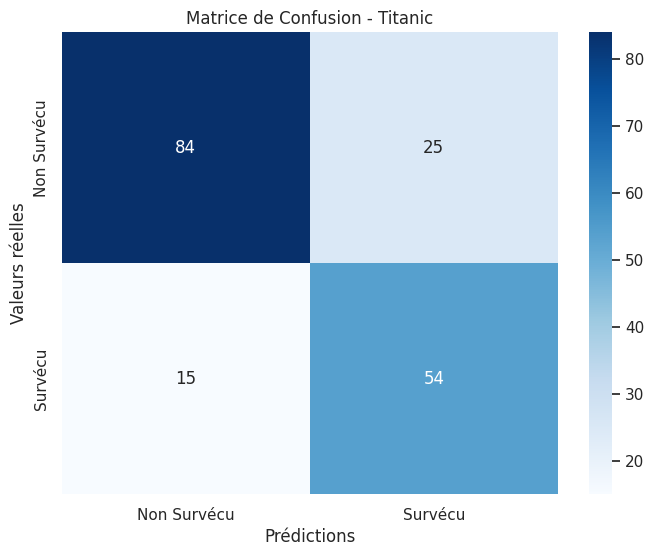

In [6]:
# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# 1. Calcul des métriques
accuracy = accuracy_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Précision (Accuracy) : {accuracy:.2f}")
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.2f}")

# 2. Rapport complet de classification
print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

# 3. Visualisation : Matrice de Confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non Survécu', 'Survécu'], yticklabels=['Non Survécu', 'Survécu'])
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.title('Matrice de Confusion - Titanic')
plt.show()